# Ajuste exacto

$$
I =  I_s \exp\left(\frac{eV}{nk_BT}-1\right)
$$

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSV con columnas:
# polarizacion, V_d_V, I_d_mA, T_K
CSV_FILE = "/home/jorge/Escritorio/Lab/Pr1/datos_diodo_mA.csv"

data = np.genfromtxt(CSV_FILE, delimiter=",", names=True, dtype=None, encoding="utf-8")

polarizacion = data["polarizacion"]
V = data["V_d_V"].astype(float)       # voltaje en V
I_mA = data["I_d_mA"].astype(float)   # corriente en mA
T = float(np.mean(data["T_K"].astype(float)))

# Modelo de Shockley escrito con beta = q/(n k_B).
# Si impones n = 1, beta se interpreta como q/k_B.
#=================================================================
def shockley(V, Is_mA, beta, n=2):
    x = beta * V / (n*T)
    return Is_mA * np.expm1(x)

# Incertidumbre efectiva para que puntos con corriente muy pequeña no dominen demasiado.
sigma_mA = np.maximum(np.abs(I_mA), 1e-9)

p0 = [1e-9, 1.0e4]  # Is en mA, beta en K/V
bounds = ([0.0, 0.0], [np.inf, np.inf])

popt, pcov = curve_fit(
    shockley,
    V,
    I_mA,
    p0=p0,
    bounds=bounds,
    sigma=sigma_mA,
    absolute_sigma=False,
    maxfev=100000,
)

Is_fit_mA, beta_fit = popt
perr = np.sqrt(np.diag(pcov))
Is_err_mA, beta_err = perr

e_over_kB = 1.16045e4  # K/V




In [4]:
print(f"T = {T:.2f} K")
print(f"Is = {Is_fit_mA*10**9:.6e} pA ± {Is_err_mA*10**9:.2e} pA")
print(f"beta = q/(n kB) = {beta_fit:.6e} K/V ± {beta_err:.2e} K/V")
print(f"e/kB exacto = {e_over_kB:.6e} K/V")

T = 297.15 K
Is = 3.490822e-01 pA ± 3.04e-01 pA
beta = q/(n kB) = 1.463037e+04 K/V ± 7.63e+02 K/V
e/kB exacto = 1.160450e+04 K/V


In [5]:
porcentaje = ((beta_fit-e_over_kB)/e_over_kB)*100
print(f"Error porcentual= {porcentaje}%")

Error porcentual= 26.074971102021845%


In [6]:
#n_eff = e_over_kB / beta_fit
#print(f"n_eff = {n_eff}")

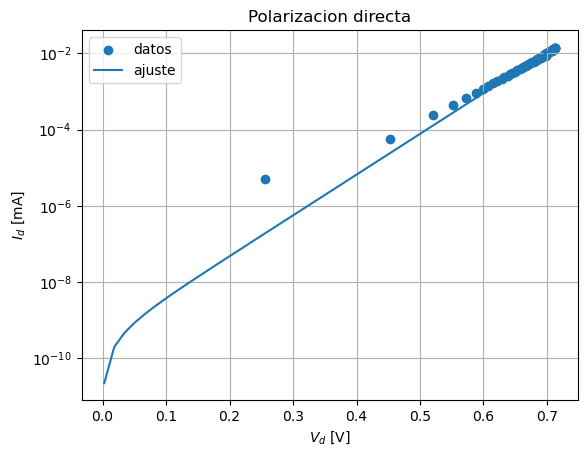

In [7]:
V_plot = np.linspace(V.min(), V.max(), 1000)
I_plot_mA = shockley(V_plot, *popt)

"""
plt.figure()
plt.scatter(V, I_mA, label="datos")
plt.plot(V_plot, I_plot_mA, label="ajuste")
plt.xlabel(r"$V_d$ [V]")
plt.ylabel(r"$I_d$ [mA]")
plt.title("Ajuste de Shockley")
plt.legend()
plt.grid(True)
plt.show()
"""

mask_directa = I_mA > 0

plt.figure()
plt.scatter(V[mask_directa], I_mA[mask_directa], label="datos")
plt.plot(V_plot[V_plot > 0], I_plot_mA[V_plot > 0], label="ajuste")
plt.yscale("log")
plt.xlabel(r"$V_d$ [V]")
plt.ylabel(r"$I_d$ [mA]")
plt.title("Polarizacion directa")
plt.legend()
plt.grid(True, which="both")
plt.show()

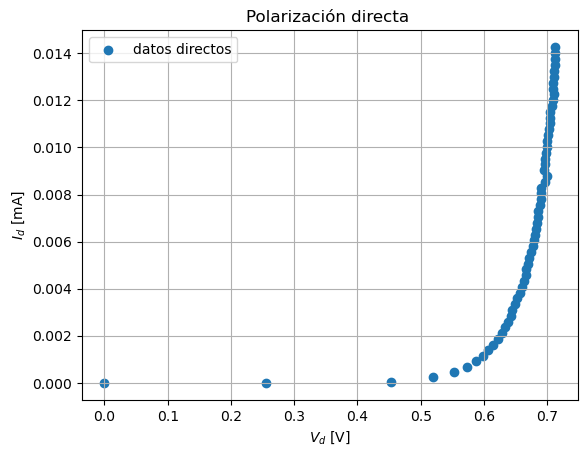

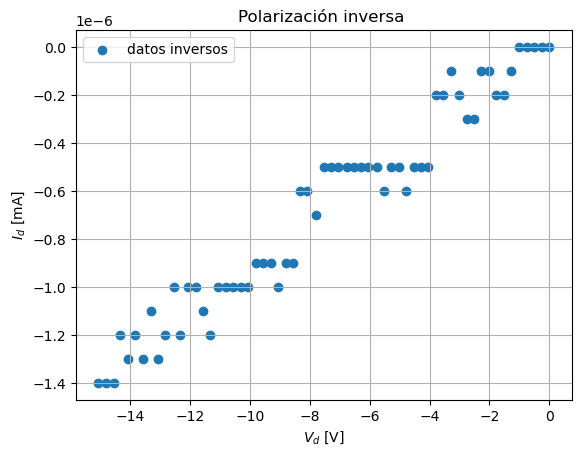

In [8]:
# ============================ Datos crudos===============

mask_directa = polarizacion == "directa"
mask_inversa = polarizacion == "inversa"

# Ordenamos los puntos solo para que, si conectas con línea, no se crucen
idx_directa = np.argsort(V[mask_directa])
idx_inversa = np.argsort(V[mask_inversa])

V_directa = V[mask_directa][idx_directa]
I_directa_mA = I_mA[mask_directa][idx_directa]

V_inversa = V[mask_inversa][idx_inversa]
I_inversa_mA = I_mA[mask_inversa][idx_inversa]


# Polarización directa cruda
plt.figure()
plt.scatter(V_directa, I_directa_mA, label="datos directos")
plt.xlabel(r"$V_d$ [V]")
plt.ylabel(r"$I_d$ [mA]")
plt.title("Polarización directa ")
plt.grid(True)
plt.legend()
plt.show()


# Polarización inversa cruda
plt.figure()
plt.scatter(V_inversa, I_inversa_mA, label="datos inversos")
plt.xlabel(r"$V_d$ [V]")
plt.ylabel(r"$I_d$ [mA]")
plt.title("Polarización inversa ")
plt.grid(True)
plt.legend()
plt.show()

# Forma Linealizada
$$
ln(I) = \frac{\beta}{nT}V \qquad \beta\equiv \frac{e}{k_B}
$$

para cuando $I>>I_s$

In [13]:

# ============================
# Ajuste linealizado de Shockle

n_fijo = 2.0

# Usamos solo polarización directa y corrientes positivas
mask = (polarizacion == "directa") & (I_mA > 0)

V_dir = V[mask]
I_dir_mA = I_mA[mask]

# Opcional: descartar corrientes muy pequeñas
# para evitar puntos dominados por ruido
umbral_mA = 1e-5
mask_umbral = I_dir_mA > umbral_mA

V_fit = V_dir[mask_umbral]
I_fit_mA = I_dir_mA[mask_umbral]

# Variable linealizada
Y = np.log(I_fit_mA)

# Ajuste lineal:
# Y = m V + b
coef, cov = np.polyfit(V_fit, Y, deg=1, cov=True)

m = coef[0]
b = coef[1]

sigma_m = np.sqrt(cov[0, 0])
sigma_b = np.sqrt(cov[1, 1])
cov_mb = cov[0, 1]

# Parámetros físicos
Is_mA = np.exp(b)
sigma_Is_mA = Is_mA * sigma_b

Is_uA = Is_mA * 1000
sigma_Is_uA = sigma_Is_mA * 1000

Is_A = Is_mA * 1e-3
sigma_Is_A = sigma_Is_mA * 1e-3

q_sobre_kB_fit = m * n_fijo * T
sigma_q_sobre_kB = n_fijo * T * sigma_m

q_sobre_kB_real = 1.16045e4

error_porcentual = (q_sobre_kB_fit - q_sobre_kB_real) / q_sobre_kB_real * 100
sigma_error_porcentual = sigma_q_sobre_kB / q_sobre_kB_real * 100

# R^2
Y_pred = m * V_fit + b
SS_res = np.sum((Y - Y_pred)**2)
SS_tot = np.sum((Y - np.mean(Y))**2)
R2 = 1 - SS_res / SS_tot


print("Ajuste lineal:")
print(f"m = ({m:.6e} ± {sigma_m:.6e}) 1/V")
print(f"b = ({b:.6e} ± {sigma_b:.6e})")
print(f"R^2 = {R2:.6f}")
print()


#print(f"Is = ({Is_uA:.6e} ± {sigma_Is_uA:.6e}) μA")

print(f"q/kB = ({q_sobre_kB_fit:.6e} ± {sigma_q_sobre_kB:.6e}) K/V")
print(f"q/kB exacto = {q_sobre_kB_real:.6e} K/V")
print(f"error porcentual = ({error_porcentual:.2f} ± {sigma_error_porcentual:.2f}) %")

Ajuste lineal:
m = (2.108096e+01 ± 1.068436e-01) 1/V
b = (-1.937001e+01 ± 7.154404e-02)
R^2 = 0.998538

q/kB = (1.252842e+04 ± 6.349717e+01) K/V
q/kB exacto = 1.160450e+04 K/V
error porcentual = (7.96 ± 0.55) %


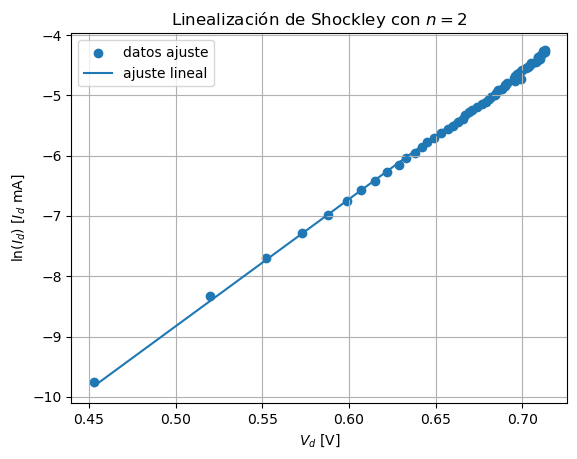

In [14]:
# ============================
# Gráfica de la linealización
# solo con datos usados en el ajuste
# ============================


V_recta = np.linspace(V_fit.min(), V_fit.max(), 300)
Y_recta = m * V_recta + b

plt.figure()

plt.scatter(
    V_fit,
    Y,
    label="datos ajuste"
)

plt.plot(
    V_recta,
    Y_recta,
    label="ajuste lineal"
)

plt.xlabel(r"$V_d$ [V]")
plt.ylabel(r"$\ln(I_d)$ [$I_d$ mA]")
plt.title(r"Linealización de Shockley con $n=2$")
plt.grid(True)
plt.legend()
plt.show()